<a href="https://colab.research.google.com/github/thienandinh29/nghiemcuukhoahocsgu2026/blob/main/raw_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. DATA SHAPE ---
Rows: 4023, Columns: 7

--- 2. MISSING VALUES ---
Close       0
High        0
Low         0
Open        0
Volume      0
Tomorrow    0
Target      0
dtype: int64

--- 3. TARGET BALANCE ---
Up Days (1): 2199
Down Days (0): 1824
Ratio: 54.66%


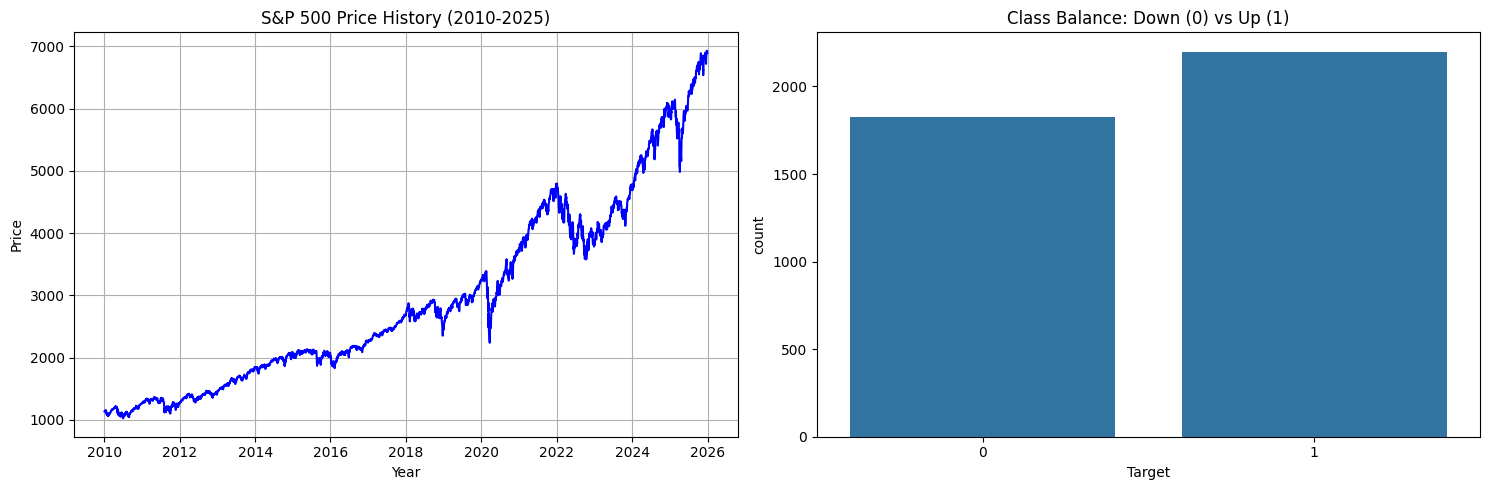


--- 4. STATISTICS ---
             Close        Volume
count  4023.000000  4.023000e+03
mean   2944.041834  4.012535e+09
std    1489.989944  9.940300e+08
min    1022.580017  0.000000e+00
25%    1805.450012  3.396175e+09
50%    2584.620117  3.835170e+09
75%    4077.255005  4.441860e+09
max    6932.049805  1.061781e+10


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# parse_dates=True ensures Python understands the "Date" column is time, not text
df = pd.read_csv("sp500_supervised_data.csv", index_col=0, parse_dates=True)

print("--- 1. DATA SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- 2. MISSING VALUES ---")
print(df.isnull().sum())

# 2. Check the Target Balance (CRITICAL for Classification)
# We want to know if "Up" (1) and "Down" (0) are roughly equal
up_days = df[df["Target"] == 1].shape[0]
down_days = df[df["Target"] == 0].shape[0]

print(f"\n--- 3. TARGET BALANCE ---")
print(f"Up Days (1): {up_days}")
print(f"Down Days (0): {down_days}")
print(f"Ratio: {up_days / (up_days + down_days):.2%}")
# ideally, this is between 45% and 55%

# 3. VISUALIZATION
plt.figure(figsize=(15, 5))

# Plot A: The Closing Price (Check for gaps or $0 errors)
plt.subplot(1, 2, 1)
plt.plot(df.index, df["Close"], label="S&P 500 Close", color="blue")
plt.title("S&P 500 Price History (2010-2025)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)

# Plot B: Target Distribution
plt.subplot(1, 2, 2)
sns.countplot(x=df["Target"])
plt.title("Class Balance: Down (0) vs Up (1)")

plt.tight_layout()
plt.show()

# 4. STATISTICAL SUMMARY
# Look at the 'min' and 'max' rows to catch impossible numbers (like negative prices)
print("\n--- 4. STATISTICS ---")
print(df[["Close", "Volume"]].describe())